In [1]:
# Բջիջ 1: Անհրաժեշտ գրադարանների ներմուծում և սարքի (Device) կարգավորում
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import copy
from PIL import Image
import os

# Ստուգում ենք GPU-ի հասանելիությունը հաշվարկները արագացնելու համար
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Օգտագործվող սարքը (Device): {device}")

Օգտագործվող սարքը (Device): cuda


In [2]:
# Բջիջ 2: Տվյալների տրանսֆորմացիա և CIFAR-10 տվյալների բազայի բեռնում
BATCH_SIZE = 64

# Տրանսֆորմացիաներ ուսուցանող ընտրանքի համար (աուգմենտացիայով)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),       # Բերում ենք ստանդարտ ResNet չափսի
    transforms.RandomHorizontalFlip(),  # Թեթև աուգմենտացիա՝ գերուսուցումից (overfitting) խուսափելու համար
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # CIFAR-10-ի միջին արժեքները
])

# Տրանսֆորմացիաներ թեստային ընտրանքի համար (առանց աուգմենտացիայի, միայն չափսի փոփոխություն)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Բեռնում ենք ամբողջական CIFAR-10 տվյալների բազան
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Առանձնացնում ենք վալիդացիոն (validation) ընտրանքը (90% train, 10% val)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Կարևոր դաս՝ վալիդացիոն տվյալների վրա test_transform կիրառելու համար
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        original_img = full_train_dataset.data[self.subset.indices[index]]
        original_img = Image.fromarray(original_img)
        return self.transform(original_img), y
    def __len__(self):
        return len(self.subset)

val_dataset = SubsetWithTransform(val_dataset, test_transform)

# Ստեղծում ենք DataLoader-ներ բատչերով աշխատելու համար
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f"Ուսուցում: {len(train_dataset)}, Վալիդացիա: {len(val_dataset)}, Թեստ: {len(test_dataset)}")

100%|██████████| 170M/170M [00:02<00:00, 74.9MB/s]


Ուսուցում: 45000, Վալիդացիա: 5000, Թեստ: 10000


In [3]:
# Բջիջ 3: Նախապես ուսուցանված ResNet18 մոդելի ստեղծում և շերտերի սառեցում
def create_model():
    """
    Բեռնում է ImageNet-ի վրա ուսուցանված ResNet18-ը, սառեցնում է ստորին շերտերը,
    և թողնում է ապասառեցված միայն layer4-ը ու վերջնական դասակարգիչը (fc):
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # 1. Սառեցնում ենք մոդելի բոլոր պարամետրերը (կշիռները չեն փոխվի)
    for param in model.parameters():
        param.requires_grad = False

    # 2. Ապասառեցնում ենք միայն layer4-ը բարձր մակարդակի հատկանիշները հարմարեցնելու համար
    for param in model.layer4.parameters():
        param.requires_grad = True

    # 3. Փոխարինում ենք վերջին լիակապ շերտը (fc) 10 դասերի համար
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 10)

    return model.to(device)

In [4]:
# Բջիջ 4: Հիպերպարամետրերի նախնական որոնում (Best Learning Rate)
learning_rates = [1e-3, 5e-4, 1e-4]
best_lr = learning_rates[0]
best_val_loss = float('inf')

print("--- Սկսվում է լավագույն Learning Rate-ի որոնումը (1 էպոխ յուրաքանչյուրի համար) ---")
criterion_search = nn.CrossEntropyLoss()

for lr in learning_rates:
    print(f"\nՓորձարկվող Learning Rate: {lr}")
    temp_model = create_model()
    # Օպտիմիզատորին փոխանցում ենք միայն ապասառեցված պարամետրերը
    optimizer_search = optim.Adam(filter(lambda p: p.requires_grad, temp_model.parameters()), lr=lr)

    # Ուսուցման փուլ (1 էպոխ)
    temp_model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_search.zero_grad()
        outputs = temp_model(inputs)
        loss = criterion_search(outputs, labels)
        loss.backward()
        optimizer_search.step()

    # Վալիդացիայի փուլ
    temp_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = temp_model(inputs)
            loss = criterion_search(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_dataset)
    print(f"Վալիդացիոն կորուստ (Loss) LR {lr}-ի համար: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lr = lr

print(f"\n✅ Լավագույն Learning Rate-ը գտնված է: {best_lr}")

--- Սկսվում է լավագույն Learning Rate-ի որոնումը (1 էպոխ յուրաքանչյուրի համար) ---

Փորձարկվող Learning Rate: 0.001
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


Վալիդացիոն կորուստ (Loss) LR 0.001-ի համար: 0.4023

Փորձարկվող Learning Rate: 0.0005
Վալիդացիոն կորուստ (Loss) LR 0.0005-ի համար: 0.3455

Փորձարկվող Learning Rate: 0.0001
Վալիդացիոն կորուստ (Loss) LR 0.0001-ի համար: 0.3042

✅ Լավագույն Learning Rate-ը գտնված է: 0.0001


In [7]:
# Բջիջ 5: Հիմնական ուսուցման ցիկլ (25 Էպոխ)
EPOCHS = 25

model = create_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=best_lr)

# Հեռացրել ենք verbose=True պարամետրը, քանի որ այն հնացած է PyTorch-ի նոր տարբերակներում
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

print(f"--- Սկսվում է հիմնական ուսուցումը: {EPOCHS} էպոխ ---")

for epoch in range(EPOCHS):
    print(f'\nԷպոխ {epoch+1}/{EPOCHS}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
            dataloader = train_loader
            dataset_size = len(train_dataset)
        else:
            model.eval()
            dataloader = val_loader
            dataset_size = len(val_dataset)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(dataloader, desc=phase.capitalize(), leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.item())
        else:
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.item())
            scheduler.step(epoch_loss)

            # Պահպանում ենք լավագույն կշիռները
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

print(f'\nՈւսուցումն ավարտվեց: Լավագույն ճշգրտությունը (Val Acc): {best_acc:.4f}')
model.load_state_dict(best_model_wts)

--- Սկսվում է հիմնական ուսուցումը: 25 էպոխ ---

Էպոխ 1/25
----------


Train Loss: 0.4392 Acc: 0.8526


Val Loss: 0.3008 Acc: 0.8966

Էպոխ 2/25
----------


Train Loss: 0.2046 Acc: 0.9322


Val Loss: 0.2766 Acc: 0.9044

Էպոխ 3/25
----------


...

Train Loss: 0.0038 Acc: 0.9998


Val Loss: 0.2785 Acc: 0.9212

Էպոխ 25/25
----------


Train Loss: 0.0036 Acc: 0.9995


Val Loss: 0.2801 Acc: 0.9198

Ուսուցումն ավարտվեց: Լավագույն ճշգրտությունը (Val Acc): 0.9234


<All keys matched successfully>

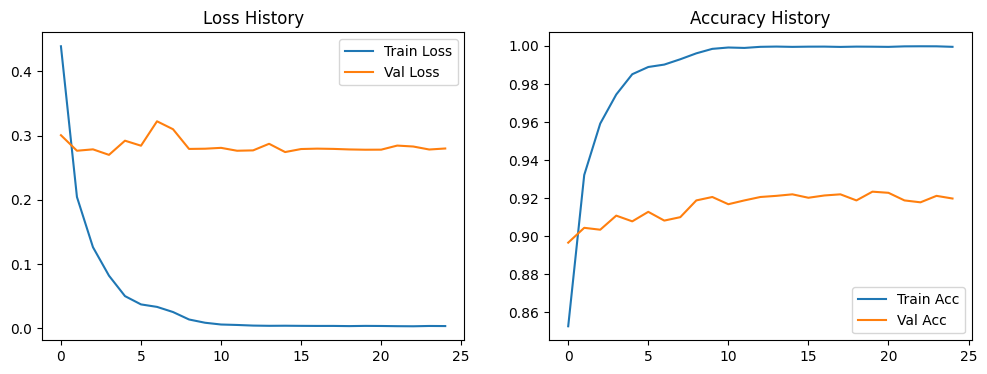

Classification Report:
              precision    recall  f1-score   support

       plane       0.94      0.95      0.94      1000
         car       0.96      0.97      0.96      1000
        bird       0.93      0.91      0.92      1000
         cat       0.87      0.82      0.85      1000
        deer       0.91      0.93      0.92      1000
         dog       0.86      0.88      0.87      1000
        frog       0.94      0.95      0.95      1000
       horse       0.95      0.94      0.94      1000
        ship       0.95      0.96      0.96      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



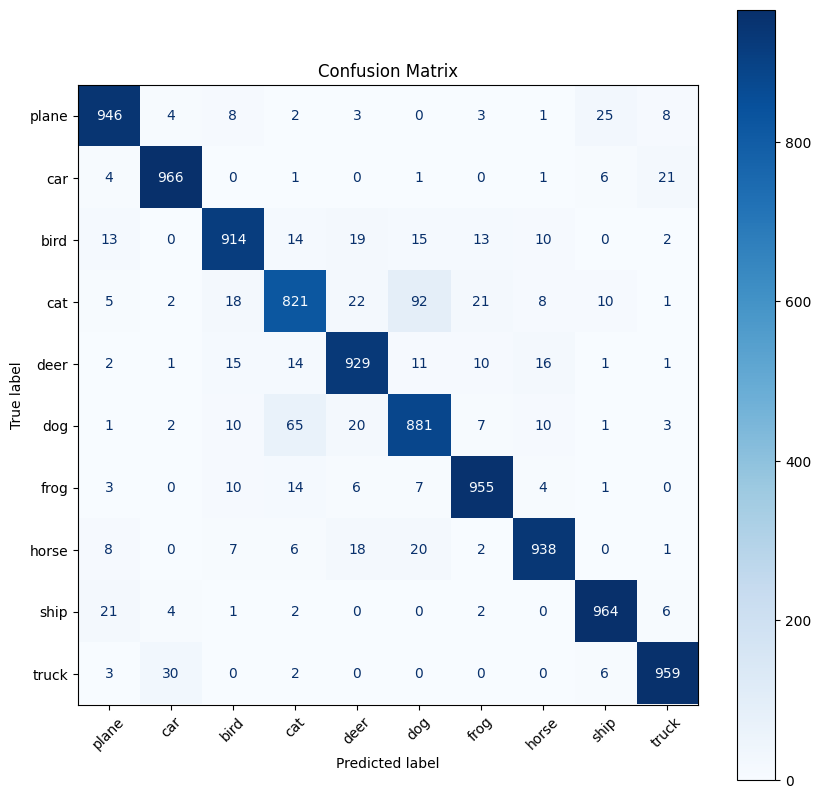

In [8]:
# Բջիջ 6: Գրաֆիկների պատրաստում և թեստային արդյունքների վերլուծություն
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy History')
plt.show()

# Գնահատում վերջնական թեստային բազայի վրա
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Սխալների մատրիցի (Confusion Matrix) պատկերում
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

--- Սկսվում է մեկ պատկերի ավտոմատ թեստավորումը ---
Պատկերը հաջողությամբ պահպանվել է այստեղ՝ /content/cifar_auto_test_image.jpg
Իրական դասը (Ground Truth): dog


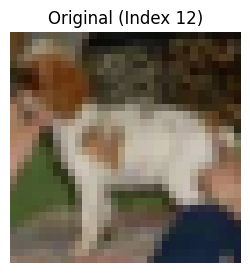

Մոդելի կանխատեսումը: dog
Վստահության մակարդակը: 100.00%
Ճիշտ կանխատեսում:


In [12]:
# Բջիջ 7: Ինֆերենս - Թեստային բազայից մեկ պատկերի ավտոմատ ներբեռնում և դասակարգում
import os
from PIL import Image

def predict_and_save_single_image(model, transform, classes, image_index=0):

    print("--- Սկսվում է մեկ պատկերի ավտոմատ թեստավորումը ---")

    # 1. Բեռնում ենք թեստային տվյալները առանց տրանսֆորմացիաների՝ մաքուր պատկեր ստանալու համար
    raw_test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

    # Վերցնում ենք պատկերը և դրա իրական դասի ինդեքսը
    pil_img, ground_truth_label = raw_test_dataset[image_index]

    # 2. Պահպանում ենք պատկերը Colab-ի սկավառակի վրա որպես JPEG ֆայլ
    test_image_path = "cifar_auto_test_image.jpg"
    pil_img.save(test_image_path)
    print(f"Պատկերը հաջողությամբ պահպանվել է այստեղ՝ {os.path.abspath(test_image_path)}")
    print(f"Իրական դասը (Ground Truth): {classes[ground_truth_label]}")

    # 3. Ցուցադրում ենք պատկերը նոթբուքում (մեծացված չափսով միայն դիտման համար)
    plt.figure(figsize=(3, 3))
    plt.imshow(pil_img)
    plt.title(f"Original (Index {image_index})")
    plt.axis('off')
    plt.show()

    # 4. Կիրառում ենք մոդելի համար անհրաժեշտ տրանսֆորմացիաները (Resize 224x224, Normalize)
    # Ավելացնում ենք բատչի չափողականությունը (unsqueeze)
    image_tensor = transform(pil_img).unsqueeze(0).to(device)

    # 5. Մոդելի միջոցով կատարում ենք կանխատեսում
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        prob, predicted = torch.max(probs, 1)

    class_name = classes[predicted.item()]
    confidence = prob.item() * 100

    print(f'Մոդելի կանխատեսումը: {class_name}')
    print(f'Վստահության մակարդակը: {confidence:.2f}%')

    if class_name == classes[ground_truth_label]:
        print("Ճիշտ կանխատեսում:")
    else:
        print("Մոդելը սխալվեց:")

# Գործարկում ենք ֆունկցիան (կարող եք փոխել image_index-ը 0-ից մինչև 9999 ցանկացած այլ պատկեր տեսնելու համար)
predict_and_save_single_image(model, test_transform, classes, image_index=12)